In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tskit
from IPython.display import SVG, display, clear_output
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.offsetbox import AnnotationBbox
import io

import cairosvg
from PIL import Image

from vscodenb import set_vscode_theme, vscode_theme
set_vscode_theme()

import matplotlib.colors

def in_dark_theme(ax=None):
    """Returns True if the background is dark, False otherwise."""
    if ax is None:
        plt.ioff()
        ax = plt.gca()
        plt.ion()        
    bg_color = ax.get_facecolor()
    # Convert to grayscale to determine brightness
    luminance = matplotlib.colors.rgb_to_hsv(matplotlib.colors.to_rgb(bg_color))[2]
    return bool(luminance < 0.5)

def draw_tree(tree, ax=None, log=False, fontsize=15, mut_color=None, tree_color=None, node_labels=False, size=(1000, 500), **kwargs):

    if isinstance(node_labels, bool):
        if node_labels:
            kwargs['node_labels'] = None
        else:
            kwargs['node_labels'] = {}

    if log:
        assert 'time_scale' not in kwargs, "Cannot specify time_scale when log=True"
        kwargs['time_scale'] = "log_time"
    elif 'time_scale' not in kwargs:
        kwargs['time_scale'] ="time"
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    if mut_color is None:
        mut_color = "#FF6700" if in_dark_theme(ax) else "red"
    if tree_color is None:
        tree_color = '#bbbbbb' if in_dark_theme(ax) else '#333333'
    tree_style = f".tree {{font-size: 14px; text-anchor: middle; fill: {tree_color} }} path.edge {{ stroke: {tree_color} }} .node .sym {{ fill: {tree_color} }} "
    mut_style = f'.mut text {{fill: {mut_color}; font-style: italic; font-size: {fontsize}px}} .mut .extra text {{fill: hotpink}} .mut line {{fill: none; stroke: none}} .mut .sym {{fill: none; stroke: {mut_color}}} .mut .extra .sym {{stroke: hotpink}} .node .mut .sym {{stroke-width: 2.5px}}'
    svg = tree.draw_svg(
        size=size,    
        style = tree_style + mut_style,
        **kwargs
    )
    # Convert SVG -> PNG in memory
    png_data = cairosvg.svg2png(bytestring=svg.encode())
    img = Image.open(io.BytesIO(png_data))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"Tree at {tree.interval.left:,.0f}–{tree.interval.right:,.0f} bp")
    plt.tight_layout()
    plt.show()


In [2]:
chrom = "chrX"
population = "CEU"

In [3]:
ts = tskit.load(f'../steps/relate/{chrom}/{population}/haplotypes_demog_trees.trees')

In [4]:
sel_results = pd.read_csv(f'../steps/relate/{chrom}/{population}/haplotypes_demog_sele.sele', sep=' ')
sel_results['logp'] = -sel_results['when_mutation_has_freq2']

In [5]:
%%html
<style> table { font-variant-numeric: tabular-nums; } </style>

In [6]:
sel_results.loc[sel_results['logp'] > 7, ['pos', 'logp']]#.style.format({'pos': '{:,.0f}', 'logp': '{:.2f}'}).hide()

,pos,logp
973,661436,8.00933
1162,730174,7.52822
2069,1096088,7.16287
2383,1268954,8.79544
2386,1270478,8.79544
2387,1270579,8.79544
2389,1270685,8.79544
3254,1611353,7.04787
30830,22124237,8.55668


In [7]:
# # top selection snp
# idx = np.argmax(sel_results.logp)
# pos = sel_results.iloc[idx].pos.item()
# pos

## Get mutation id

Mutations live on sites, and sites have positions. A site can have multiple mutations, so you get the site first:

In [8]:
# pos = 3713920 # PRKX
pos = 130491811 # RBMX2


# Get site at a specific position
site = ts.site(position=pos)  # looks up by position

# All mutations at that site
for mut in site.mutations:
    print(mut.id, mut.node, mut.derived_state)

# If there's just one:
mut_id = site.mutations[0].id

220761 4161507 T


If you need to search by approximate position or find the nearest site:


In [9]:
# import numpy as np

# pos = 130491811 + 5000000 

# positions = ts.sites_position  # array of all site positions
# idx = np.searchsorted(positions, pos)
# site = ts.site(idx)
# for mut in site.mutations:
#     print(mut.id, mut.node, mut.derived_state)

**Note:** `ts.site(pos)` with a float does a position lookup, while `ts.site(integer_id)` does an ID lookup. If your position happens to be an integer, be explicit:

```python
site = ts.site(position=pos)  # by position
site = ts.site(id=site_id)    # by ID
````

## Get the node below a mutation

A mutation sits on a specific node (the node where it arose):

In [10]:
mut = ts.mutation(mut_id)
node = mut.node
node

4161507

In [11]:
tree = ts.at(pos)
tree

In [12]:
all_leaves = list(tree.leaves(tree.root))
leaves = list(tree.leaves(node))
len(leaves), len(all_leaves)

(142, 271)

In [13]:
sel_results.loc[sel_results['logp'] > 6, ['pos', 'logp']]


,pos,logp
563,518013,6.86599
672,565216,6.77029
681,571732,6.50927
961,657768,6.96368
963,660435,6.40811
973,661436,8.00933
1162,730174,7.52822
2069,1096088,7.16287
2070,1096291,6.86057
2383,1268954,8.79544


In [14]:
pvals = dict(sel_results.loc[sel_results['logp'] > 5, ['pos', 'logp']].itertuples(index=False))



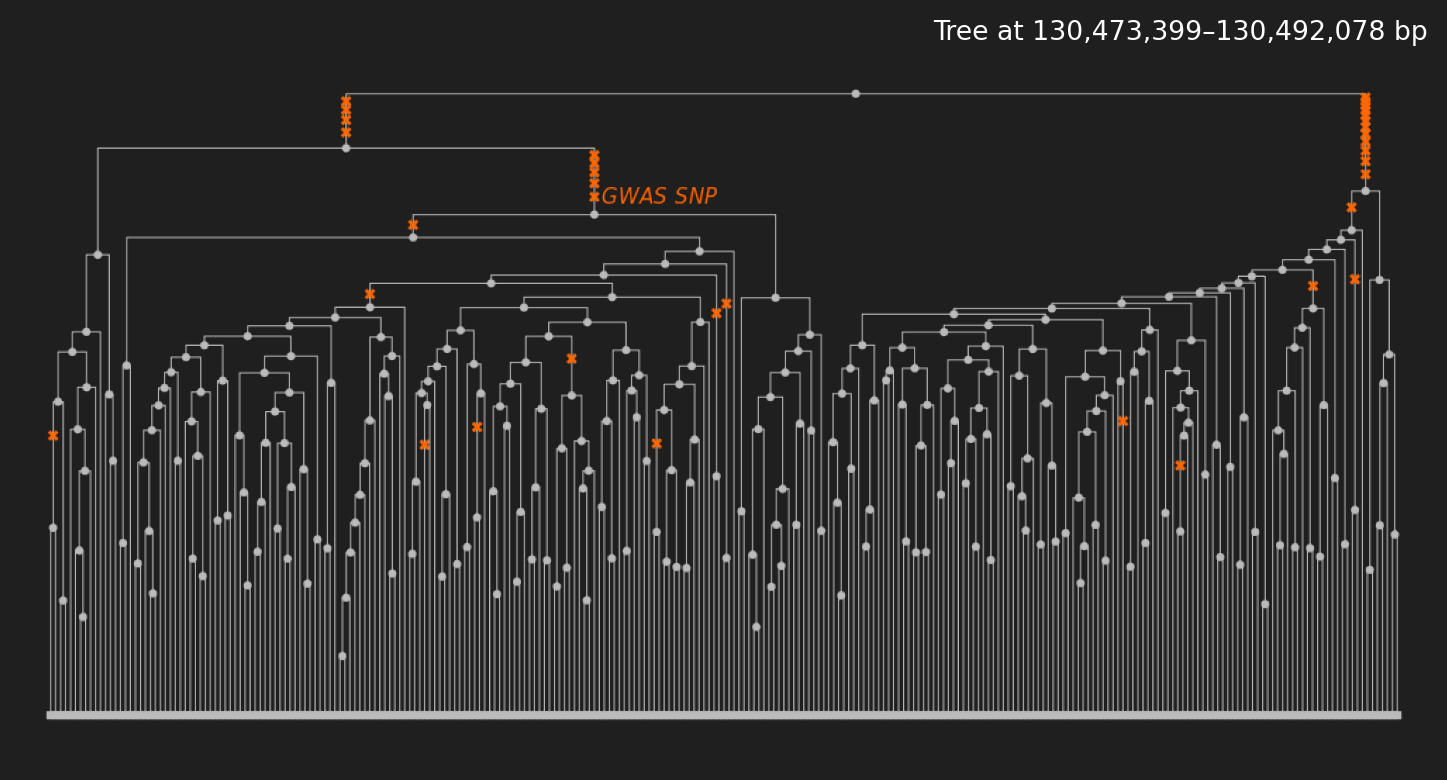

In [15]:
draw_tree(tree, mutation_labels={220761: "GWAS SNP"}, log=True)

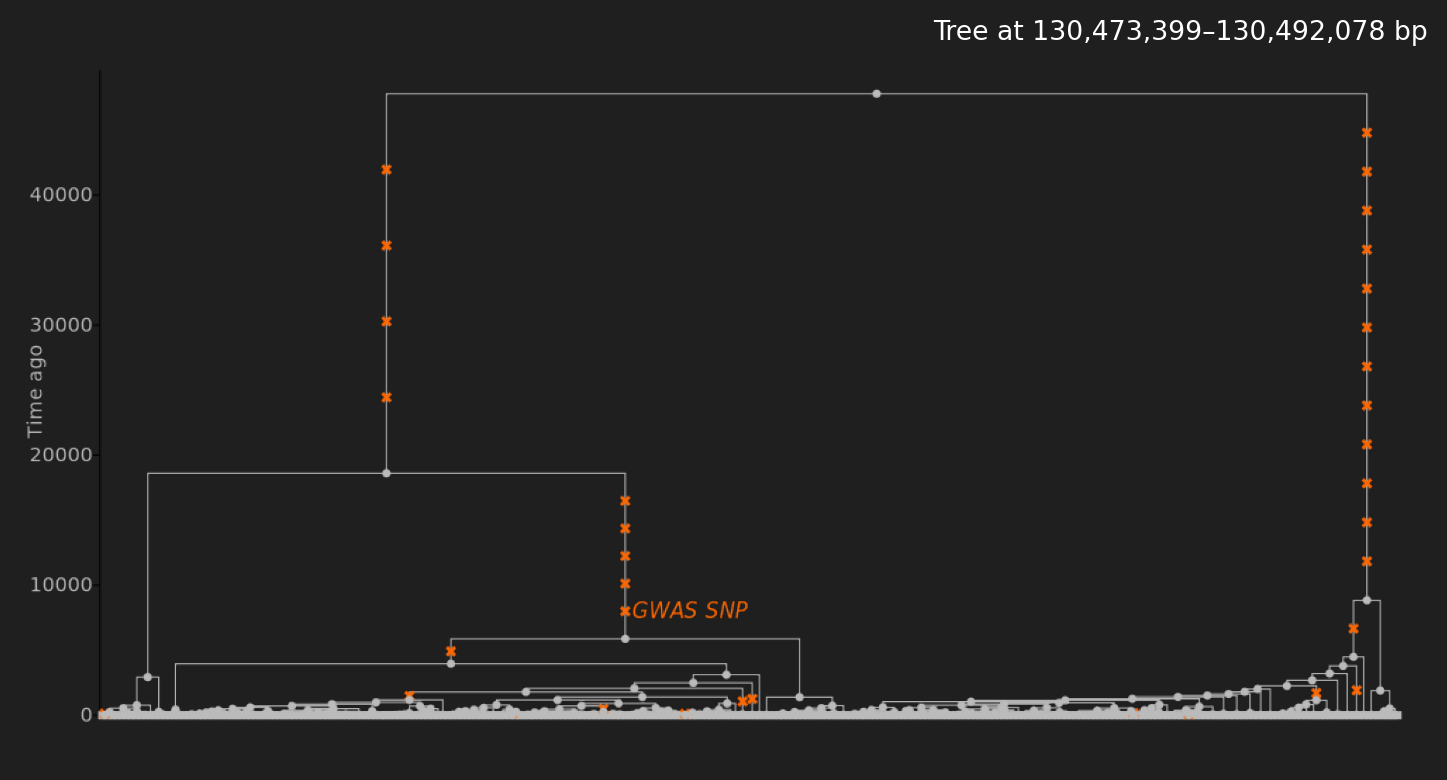

In [16]:

mutation_labels = {mut.id: f"{pvals.get(site.position, ''):.2}" for site in tree.sites() for mut in site.mutations}
mutation_labels[220761] = "GWAS SNP"


draw_tree(tree,
        y_axis=True, y_ticks=[0, 10000, 20000, 30000, 40000],
        mutation_labels=mutation_labels,
        #   mutation_labels={mut.id: mut.derived_state for mut in site.mutations},
          
        #   mutation_attrs={'fill': 'blue'}
          )# lambda mut: {"fill": "red" if mut.id == 0 else "blue"})

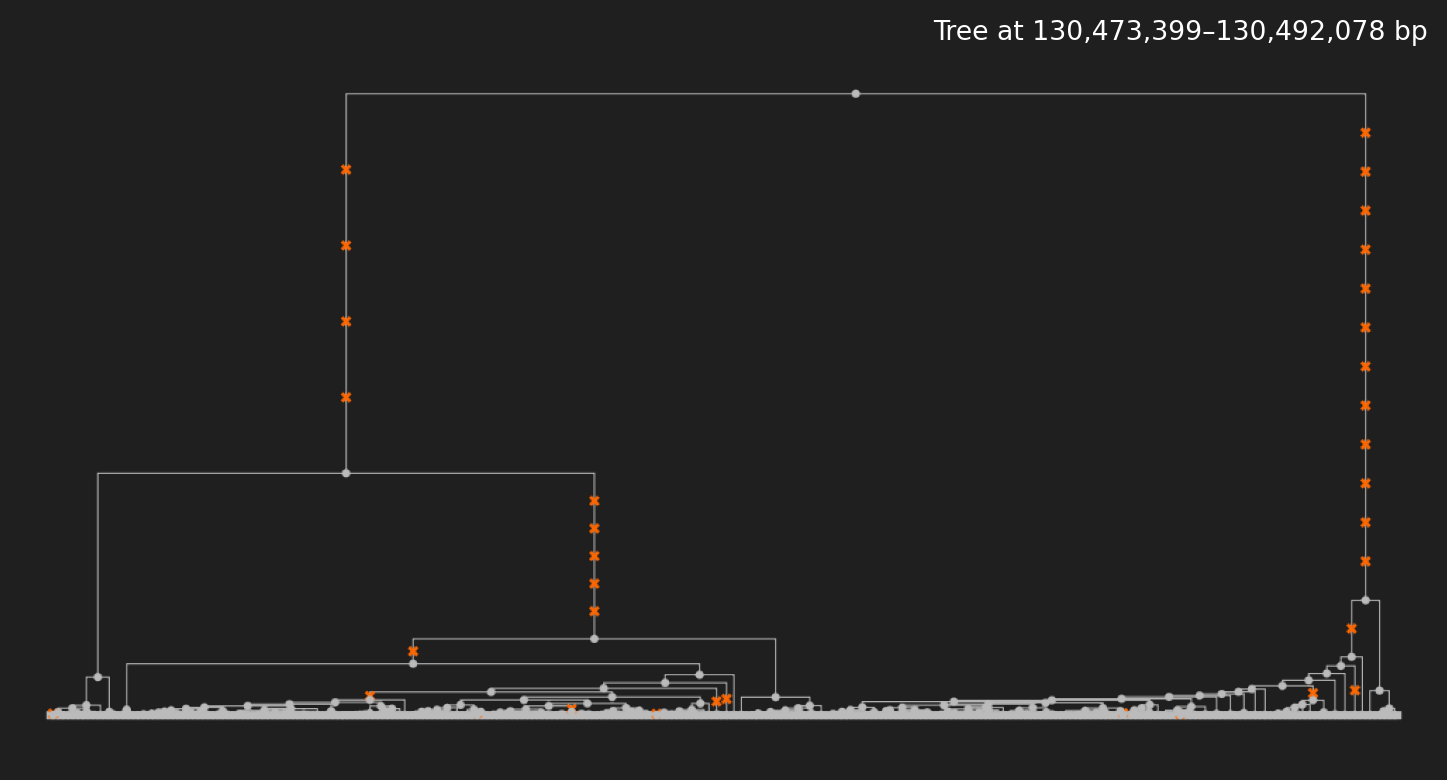

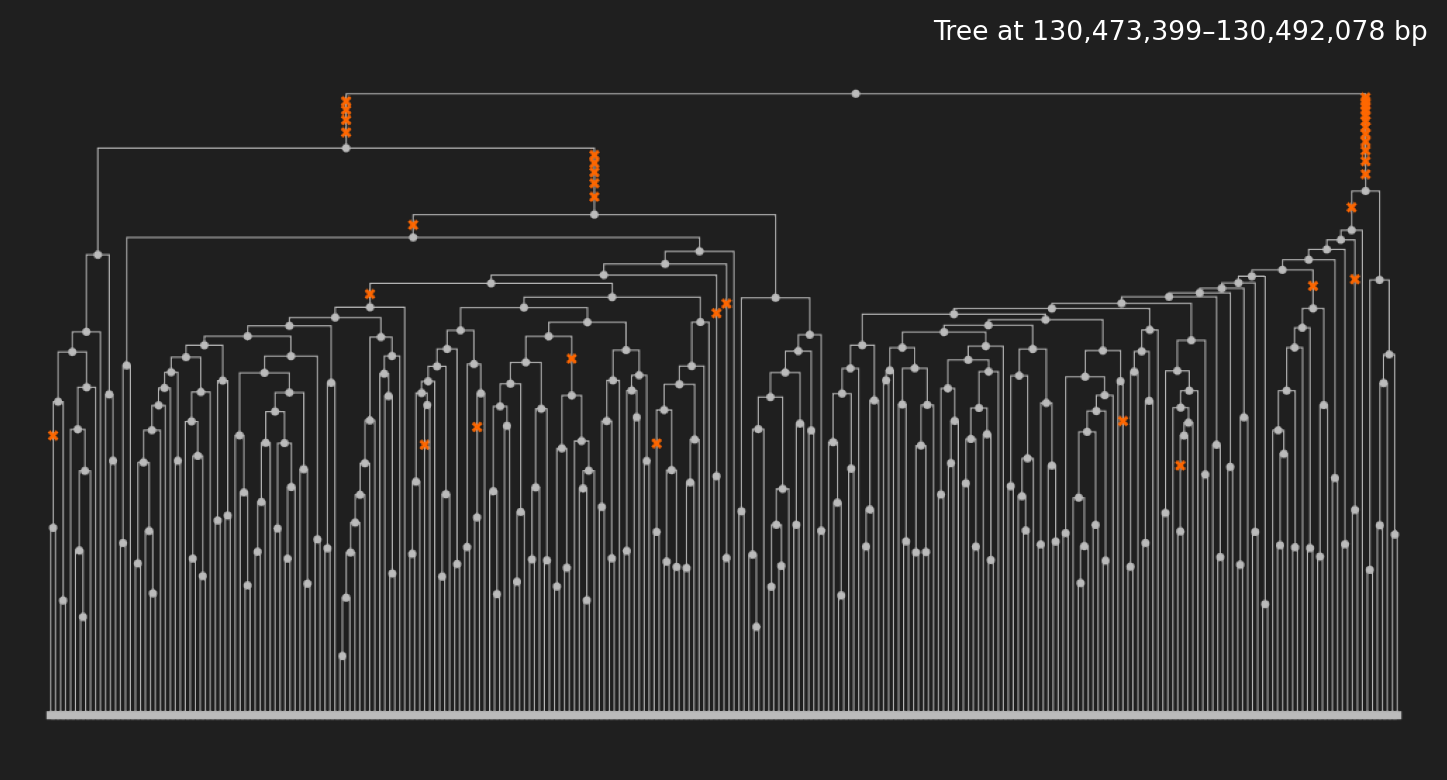

(None, None)

In [17]:
mutation_labels={mut.id: f"{pvals.get(site.position, ''):.2}" for site in tree.sites() for mut in site.mutations}
draw_tree(tree, log=False, mutation_labels=mutation_labels), draw_tree(tree, log=True, mutation_labels=mutation_labels)

In [18]:
# svg = tree.draw_svg()
# # Find lines containing "mut" or the mutation's derived state
# for line in svg.split("\n"):
#     if "mut" in line.lower() or "Mutation" in line:
#         print(line)

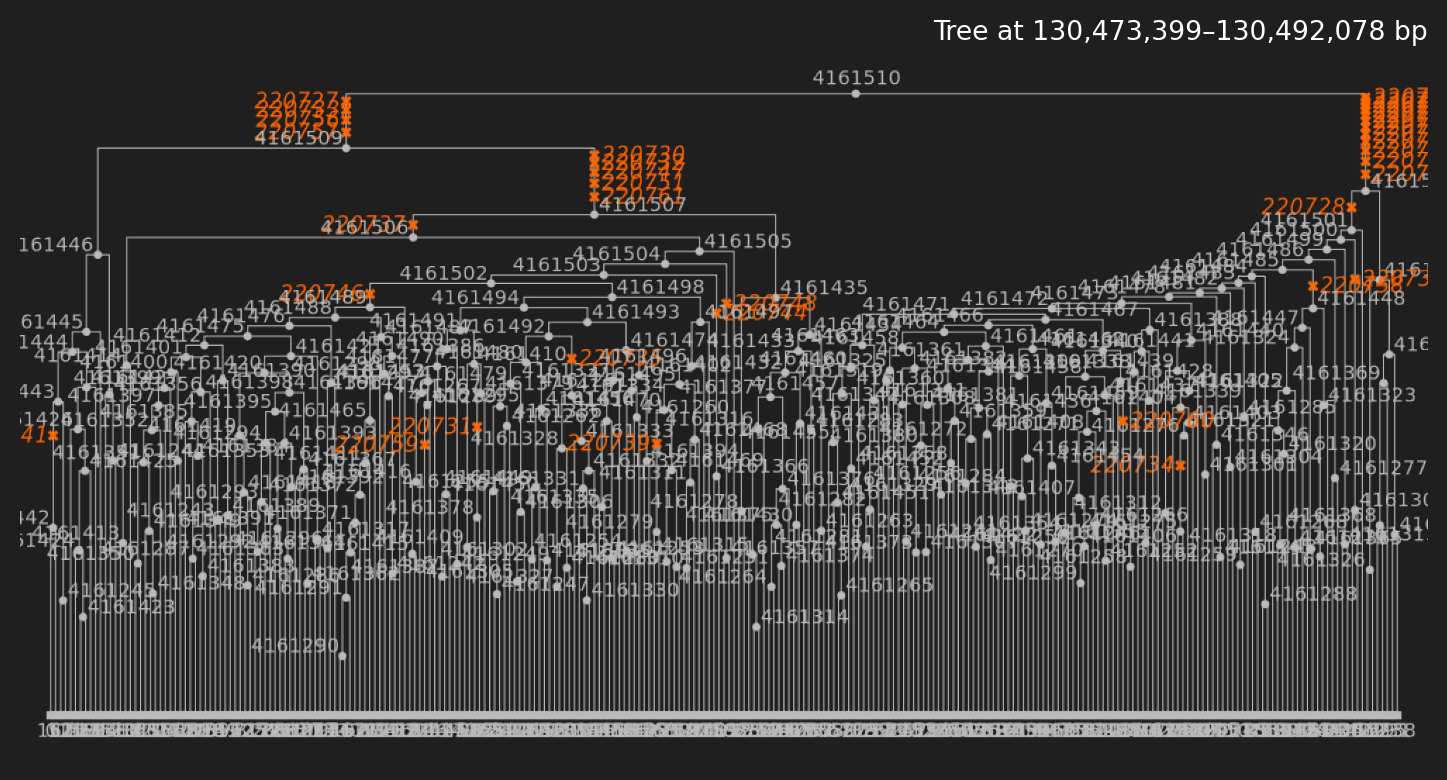

In [19]:
draw_tree(tree, log=True, node_labels=True)

## Get a new tree sequence containing with only the lineages under a node

In [20]:
# for a single tree (interval)
left, right = tree.interval
sub_ts = ts.keep_intervals([[left, right]]).trim()
sub_ts = sub_ts.simplify(samples=list(tree.leaves(node)))

# # for the entire ts
# sub_ts = ts.simplify(samples=list(tree.leaves(node)), keep_input_roots=False)
sub_ts

If you only want the single tree at that position:

In [21]:
sub_ts_pos = pos - left
sub_tree = sub_ts.at(sub_ts_pos)

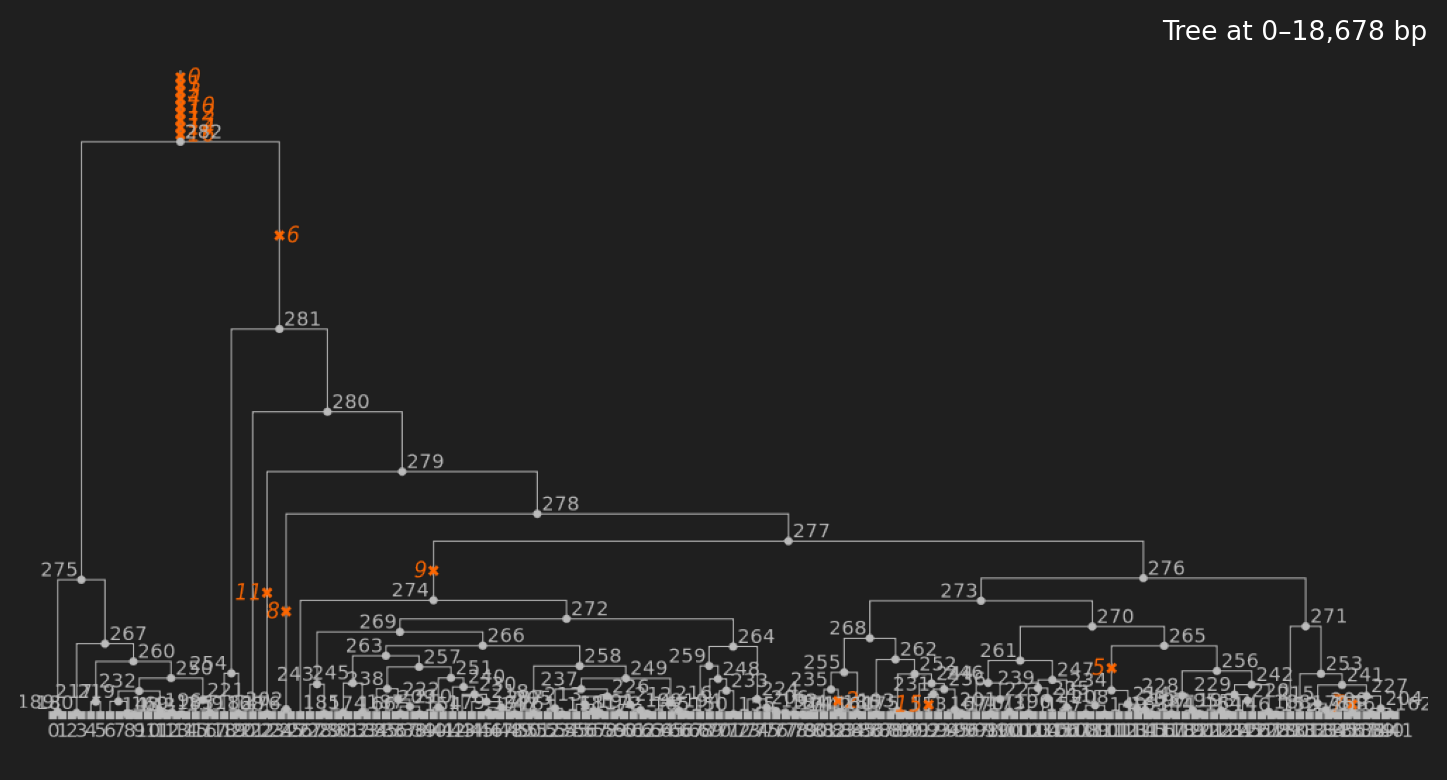

In [22]:
draw_tree(sub_tree, log=False, node_labels=True)

In [23]:
left, right = tree.interval
sub_ts = ts.keep_intervals([[left, right]]).trim()
sub_ts = sub_ts.simplify(samples=list(tree.leaves(4161446)))


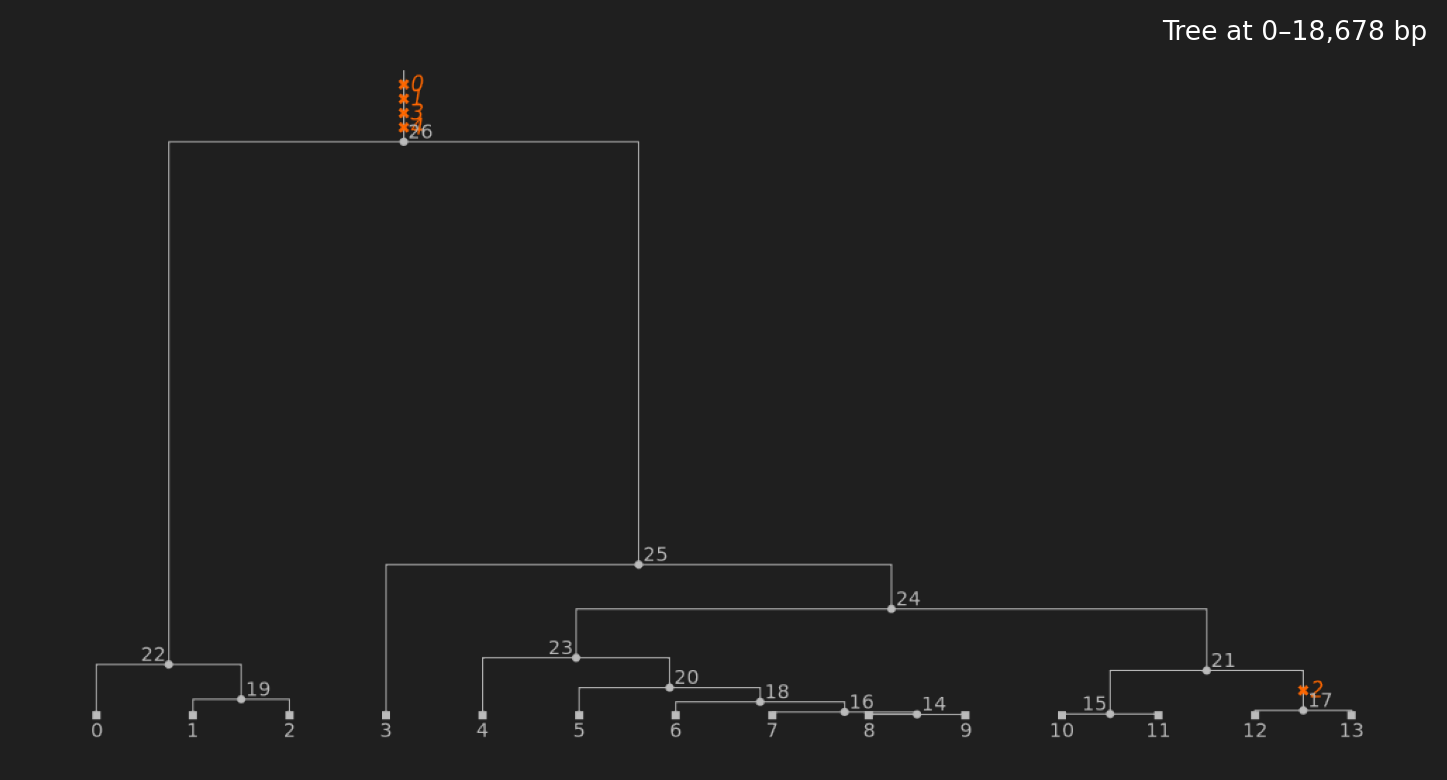

In [24]:
sub_ts_pos = pos - left
sub_tree = sub_ts.at(sub_ts_pos)
draw_tree(sub_tree, log=False, node_labels=True)

In [167]:
from itertools import takewhile
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from collections import defaultdict

def plot_tree(t, 
              ax=None, 
              leaf_colors=None, 
              show_node_ids=False, 
              show_mutations=True,
              fontsize=7, 
              alpha=1,
              text_offset=0, 
              leaf_order=None,
              margins=(0.5, 1, 0.5, 1), 
              invert=False,
              return_leaf_coords=False,
              align_labels=False): # top, right, bottom, left

    if leaf_order is None:
        leaf_order = list(range(t.num_samples()))

    return_ax = False
    if ax is None:   
        return_ax = True
        fig, ax = plt.subplots(figsize=(6, 4))

    branch_muts = defaultdict(list)
    for site in t.sites():
        for mut in site.mutations:
            branch_muts[mut.node].append(mut)
    mut_positions = {}  # mut.id -> (x, y)

    x_offsets = {}
    y_offsets = {}

    y_offset = len(list(t.leaves(t.root)))
    for node in t.nodes(order="preorder"):
        x_offsets[node] = t.time(node) 

    for node in leaf_order:
        y_offset -= 1
        y_offsets[node] = y_offset
            
    for node in t.nodes(order="postorder"):        
        if not t.is_leaf(node):
            children = t.children(node)
            y_offsets[node] = sum(y_offsets[x] for x in children) / len(children)

    horizontal_lines = list()
    vertical_lines = list()
    node_coords = list()
    leaf_coords = list()
    node_labels = list()
    max_x_offset = 0
    for node in t.nodes(order="postorder"):        
        max_x_offset = max(max_x_offset, x_offsets[node])
        node_coords.append((x_offsets[node], y_offsets[node]))
        if t.is_leaf(node):
            leaf_coords.append([str(node), x_offsets[node], y_offsets[node]])
        if not t.is_root(node):
            y = y_offsets[node]
            horizontal_lines.append(([x_offsets[t.parent(node)], x_offsets[node]], [y, y]))

            muts = branch_muts[node]
            parent = t.parent(node)
            t_child = t.time(node)
            t_parent = t.time(parent)
            n = len(muts)
            for i, mut in enumerate(muts):
                frac = (i + 1) / (n + 1)
                x = t_child + frac * (t_parent - t_child)
                mut_positions[mut.id] = (-x, y)        


        if not t.is_leaf(node):
            c = sorted(t.children(node), key=lambda x: y_offsets[x])
            bottom, top = c[0], c[-1]
            x = x_offsets[node]
            vertical_lines.append(([x, x],[y_offsets[bottom], y_offsets[top]]))
            y = (y_offsets[bottom] + y_offsets[top]) / 2

            # strings =[str(x) for x in c]
            # prefix = ''.join(c[0] for c in takewhile(lambda x: all(x[0] == y for y in x), zip(*strings)))

            # df = data.loc[data.haplotype.str.startswith(prefix)]
            # suffix = f'({df.loc[df.case == 1].index.size}/{df.loc[df.case == 0].index.size})'

            # label  = prefix + ' ' + suffix
            # node.name = prefix
            node_labels.append((-x, y, str(node)))




    for i in range(len(horizontal_lines)):
        horizontal_lines[i][0][0] *= -1
        horizontal_lines[i][0][1] *= -1
    for i in range(len(vertical_lines)):
        vertical_lines[i][0][0] *= -1
        vertical_lines[i][0][1] *= -1
    for i in range(len(leaf_coords)):
        leaf_coords[i][1] *= -1


    if in_dark_theme(ax):
        foreground_color = 'white'
        label_color = 'grey'
        mut_color = 'hotpink'
    else:
        foreground_color = 'black'
        label_color = 'lightgrey'
        mut_color = 'hotpink'

    # draw the tree:
    for x in horizontal_lines:
        ax.plot(*x, c=foreground_color, linewidth=0.8, alpha=alpha)
    for x in vertical_lines:
        ax.plot(*x, c=foreground_color, linewidth=0.8, alpha=alpha)

    if show_node_ids:
        d = max_x_offset / 200
        d = -d if invert else d
        for x, y, txt in node_labels:
            ax.text(x-d, y, txt, fontsize=fontsize, 
                    horizontalalignment='left' if invert else 'right',
                    verticalalignment='bottom', color=label_color)

    for name, x, y in leaf_coords:
                
        if align_labels:
            ax.text(0+text_offset, y, name, fontsize=fontsize,
                    verticalalignment='center', horizontalalignment='right' if invert else 'left')
            if leaf_colors is None:
                color = 'black'
            else:
                color = leaf_colors[name]
            ax.plot(x, y, c=color, marker="o", ms=3)
            ax.add_line(Line2D((x, text_offset), (y, y), linewidth=0.8, color='grey', linestyle='dashed', zorder=0))
        else:
            ax.text(x+text_offset, y, name, fontsize=fontsize,
                    verticalalignment='center', horizontalalignment='right' if invert else 'left'
                    )
            if leaf_colors is None:
                color = 'black'
            else:
                color = leaf_colors[name]
            ax.plot(x, y, c=color, marker="o", ms=3)

    if show_mutations:
        mutation_markers = []
        for node in t.nodes(order="postorder"):
            if node in mut_positions:
                mutation_markers.append(mut_positions[node])
        ax.scatter(*zip(*mutation_markers), c=mut_color, marker="x", s=30, zorder=10)

    ax.set_xlim(-margins[3]-max_x_offset, margins[1])
    ax.set_ylim(-margins[2], len(leaf_coords)-1+margins[0])

    ax.get_yaxis().set_visible(False)

    ax.spines['top'].set_visible(False) 
    ax.spines['left'].set_visible(False) 
    ax.spines['right'].set_visible(False)
    
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    if invert:
        ax.invert_xaxis()
        
    ret_val = []
    if return_ax:
        ret_val.append(ax)
    if return_leaf_coords:
        ret_val.append(leaf_coords)
    if ret_val:
        return ret_val
    # plt.tight_layout()
    # plt.show()    

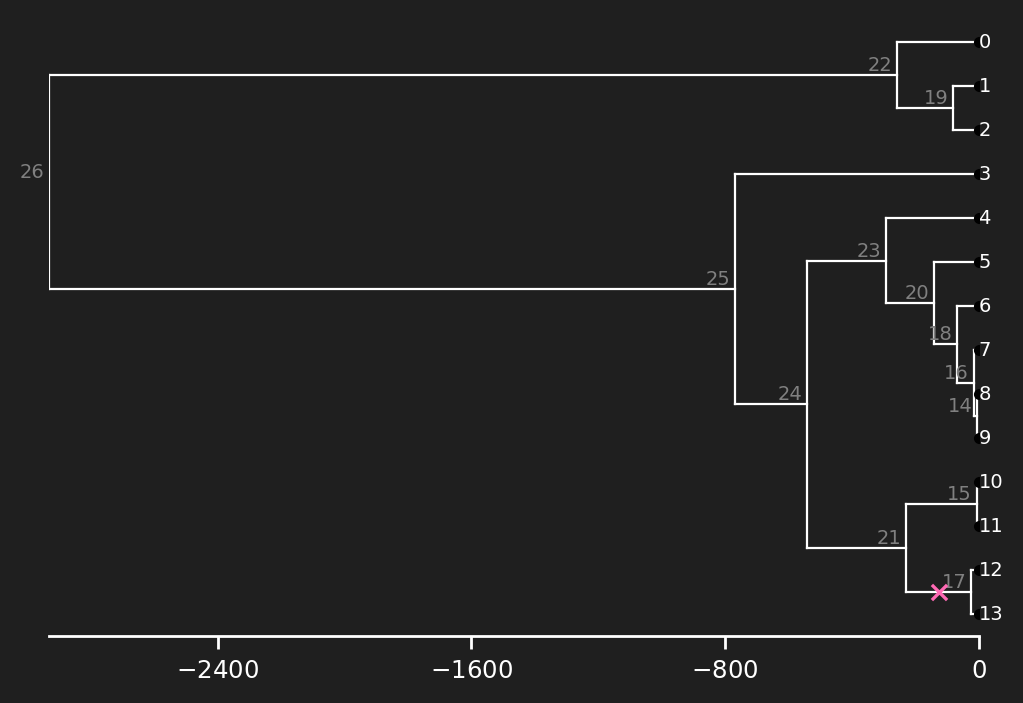

In [168]:
with vscode_theme(style='ticks'):
    plot_tree(sub_tree,        
                          show_node_ids=True,            
                            # invert=True
                          )

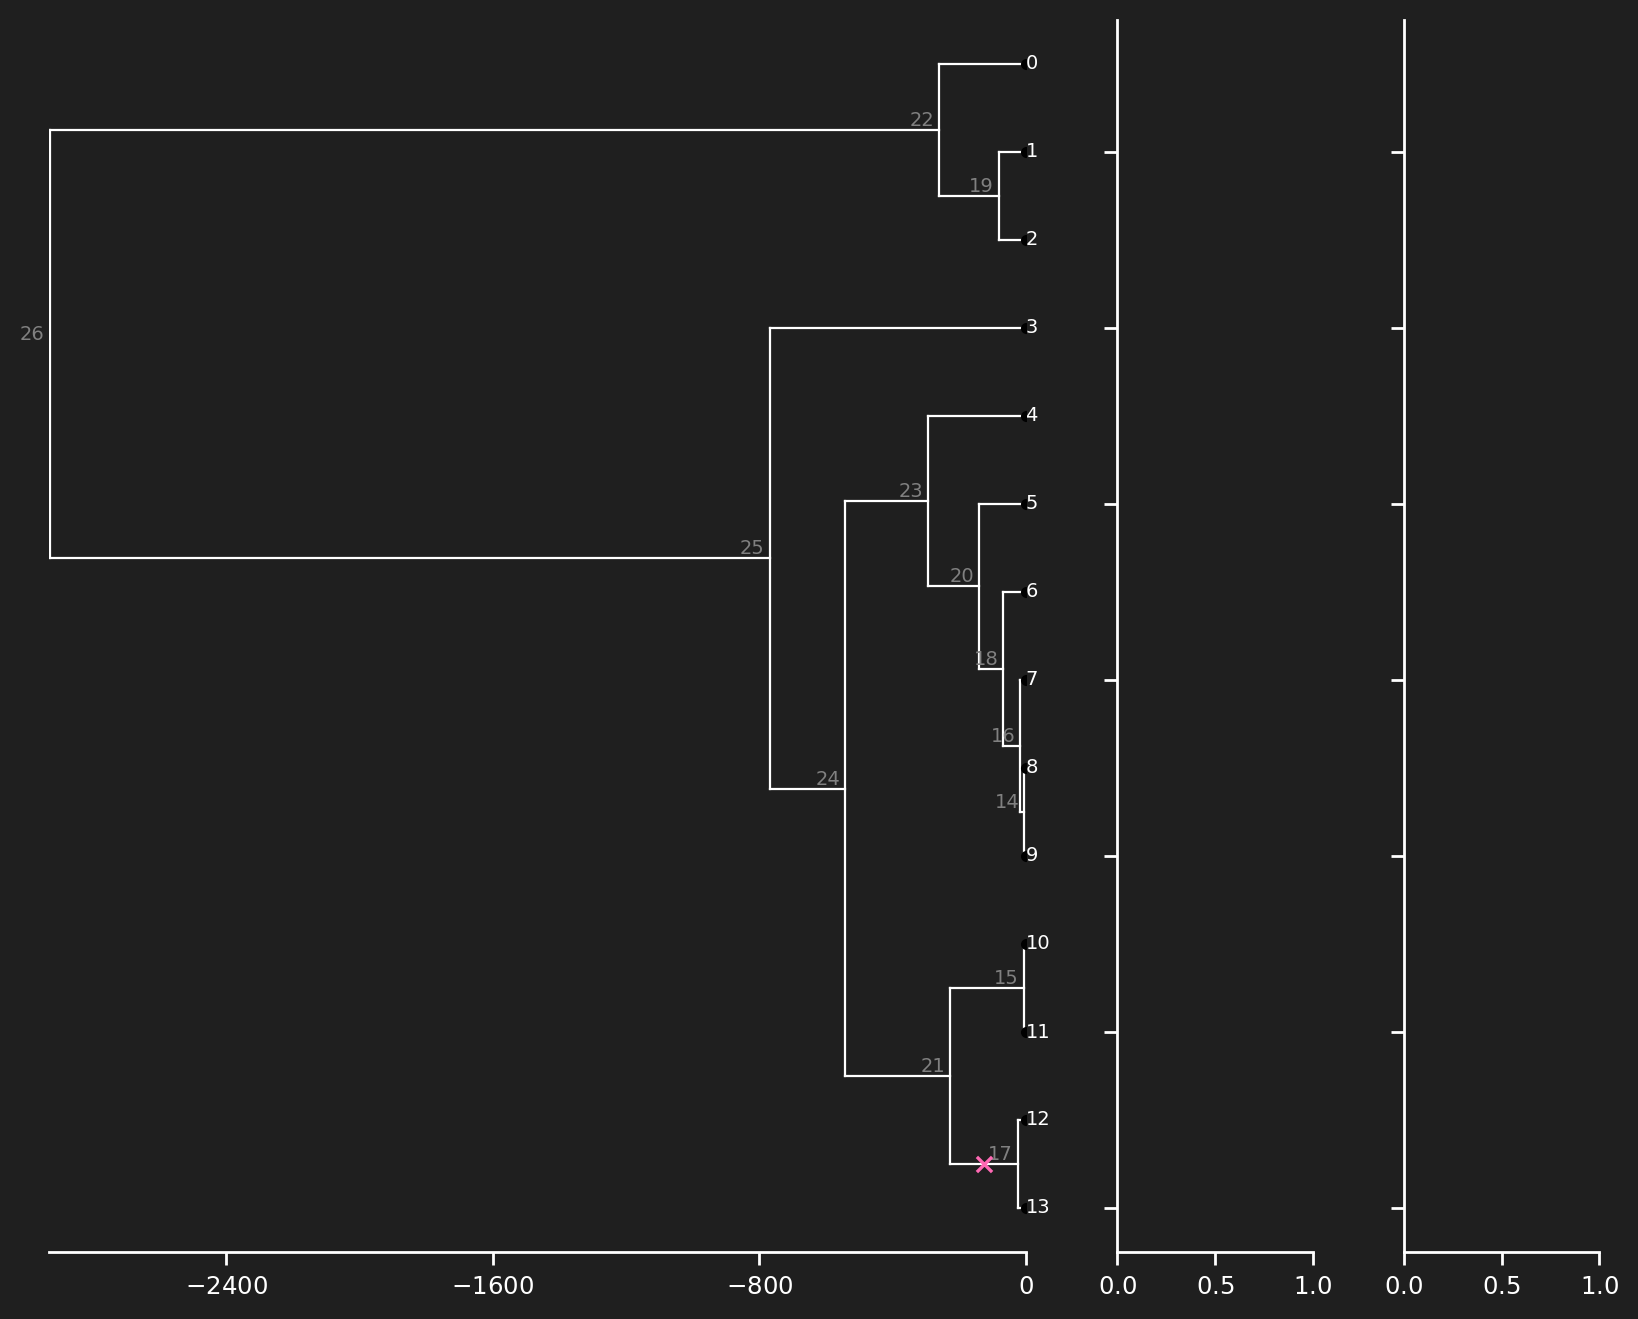

In [169]:
with vscode_theme(style='ticks'):
    fig, ax = plt.subplots(1, 3, figsize=(10, 8), width_ratios=[5, 1, 1], sharey=True)
    plot_tree(sub_tree, ax[0], show_node_ids=True)


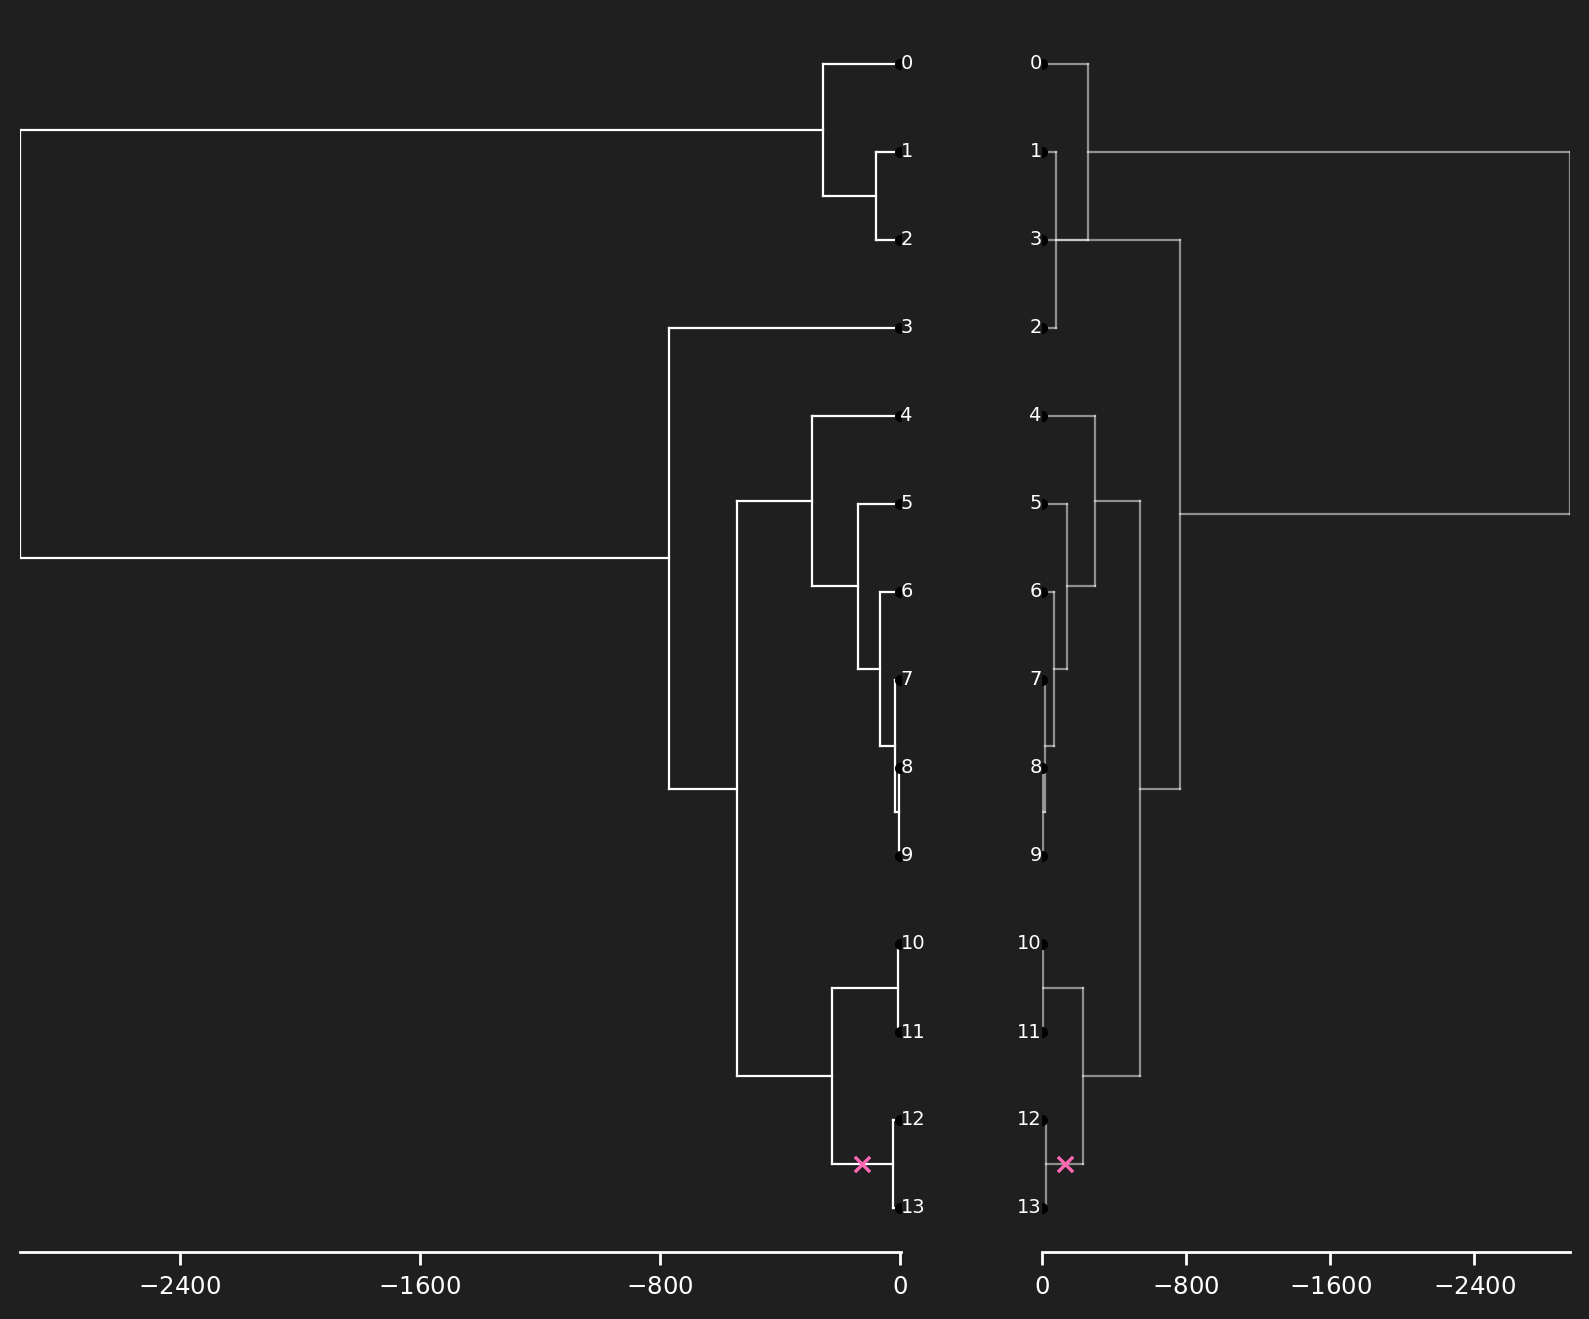

In [172]:
with vscode_theme(style='ticks'):
    fig, ax = plt.subplots(1, 2, figsize=(10, 8), width_ratios=[5, 3], sharey=True)
    plot_tree(sub_tree, ax=ax[0])
    plot_tree(sub_tree, ax=ax[1], invert=True, alpha=0.5,leaf_order=[0, 1, 3, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13])

In [ ]:

with vscode_theme(style='ticks'):
    # fig, ax = plt.subplots(1, 3, figsize=(10, 8), width_ratios=[5, 1, 1], sharey=True)

    leaf_info = plot_tree(sub_tree, 
                        #   ax[0], 
                          show_node_ids=True,
                          text_offset=0.1, margins=(1, 0.1, 1, 0.1), fontsize=7)





# base = 0
# for _ in range(5):
#     width = np.random.random(size=len(haplotypes))
#     ax[1].barh(width=width, y=list(range(len(haplotypes))))
#     base += width

# df = pd.DataFrame({hap: np.random.normal(loc=np.random.random()*10, scale=0.5, size=100) for i, hap in enumerate(haplotypes)}).reset_index().melt(id_vars='index', var_name='haplotype', value_name='value')
# sns.boxplot(data=df, x="value", y="haplotype", ax=ax[2], orient='h')

plt.tight_layout()

## Get the span of a node

In [26]:
edges = ts.tables.edges
mask = edges.child == node
left = edges.left[mask].min().item()
right = edges.right[mask].max().item()
right - left

18678.5

## Trees that share a particular node

A node exists in trees spanning the genomic interval where it has an edge. Use TreeSequence.edge or filter by the node's edges:

In [27]:
edges = ts.tables.edges
mask = (edges.child == node) | (edges.parent == node)

trees_with_node = []
seen = set()
for left in edges.left[mask]:
    tree = ts.at(left)
    if tree.index not in seen:
        seen.add(tree.index)
        trees_with_node.append(tree.copy())
trees_with_node

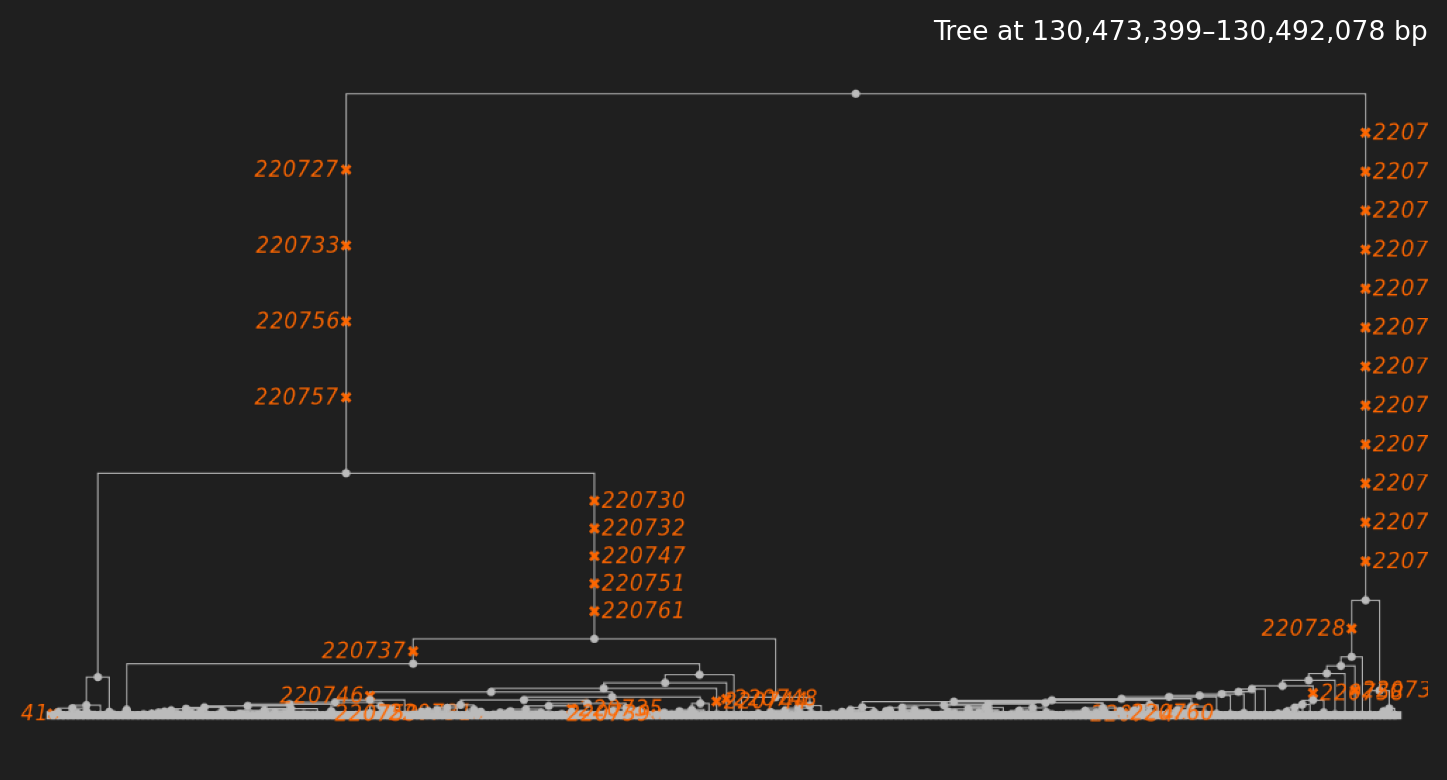

In [28]:
draw_tree(trees_with_node[0])

For non-root internal nodes, checking tree.parent(node_id) != tskit.NULL suffices. For roots you'd also check tree.num_children(node_id) > 0.

## Mutations below a node across all trees carrying that node

In [29]:
mutations_below = []
for tree in ts.trees():
    if tree.parent(node) == tskit.NULL and tree.num_children(node) == 0:
        continue  # node not in this tree
    desc = set(tree.nodes(node))
    # desc.discard(node_id)  # "below" = strict descendants
    for site in tree.sites():
        for mut in site.mutations:
            if mut.node in desc:
                mutations_below.append(mut)
mutations_below                

[Mutation(id=220730, site=228348, node=4161507, derived_state='G', parent=-1, metadata=b'', time=nan, edge=10337701, inherited_state='C'),
 Mutation(id=220731, site=228349, node=4161378, derived_state='G', parent=-1, metadata=b'', time=nan, edge=6509789, inherited_state='A'),
 Mutation(id=220732, site=228350, node=4161507, derived_state='T', parent=-1, metadata=b'', time=nan, edge=10337701, inherited_state='A'),
 Mutation(id=220735, site=228353, node=4161334, derived_state='G', parent=-1, metadata=b'', time=nan, edge=8746350, inherited_state='A'),
 Mutation(id=220737, site=228355, node=4161506, derived_state='C', parent=-1, metadata=b'', time=nan, edge=10221275, inherited_state='A'),
 Mutation(id=220739, site=228357, node=4161279, derived_state='A', parent=-1, metadata=b'', time=nan, edge=5822738, inherited_state='G'),
 Mutation(id=220744, site=228362, node=4161366, derived_state='C', parent=-1, metadata=b'', time=nan, edge=9893226, inherited_state='T'),
 Mutation(id=220746, site=22836

If you want to include mutations on the node itself, keep `node_id` in `desc`.

## Mutations in a tree not sharing ancestry with a given mutation

You want mutations on lineages that don't descend from (or are ancestral to) the focal mutation's node.

In [30]:
#focal_node = node
focal_node = 4329

focal_ancestors = set()
u = focal_node
while u != tskit.NULL:
    focal_ancestors.add(u)
    u = tree.parent(u)

focal_descendants = set(tree.nodes(focal_node))
related = focal_ancestors | focal_descendants

independent_muts = [
    m for s in tree.sites()
    for m in s.mutations
    if m.node not in related
]
[mut.id for mut in independent_muts]

[267369,
 267370,
 267371,
 267372,
 267373,
 267374,
 267375,
 267376,
 267377,
 267378,
 267379,
 267380,
 267381,
 267382,
 267383,
 267384,
 267385]

In [31]:
import matplotlib.pyplot as plt
import numpy as np

lefts = []
rights = []
tmrcas = []

for tree in ts.trees():
    lefts.append(tree.interval.left)
    rights.append(tree.interval.right)
    tmrcas.append(tree.time(tree.root))


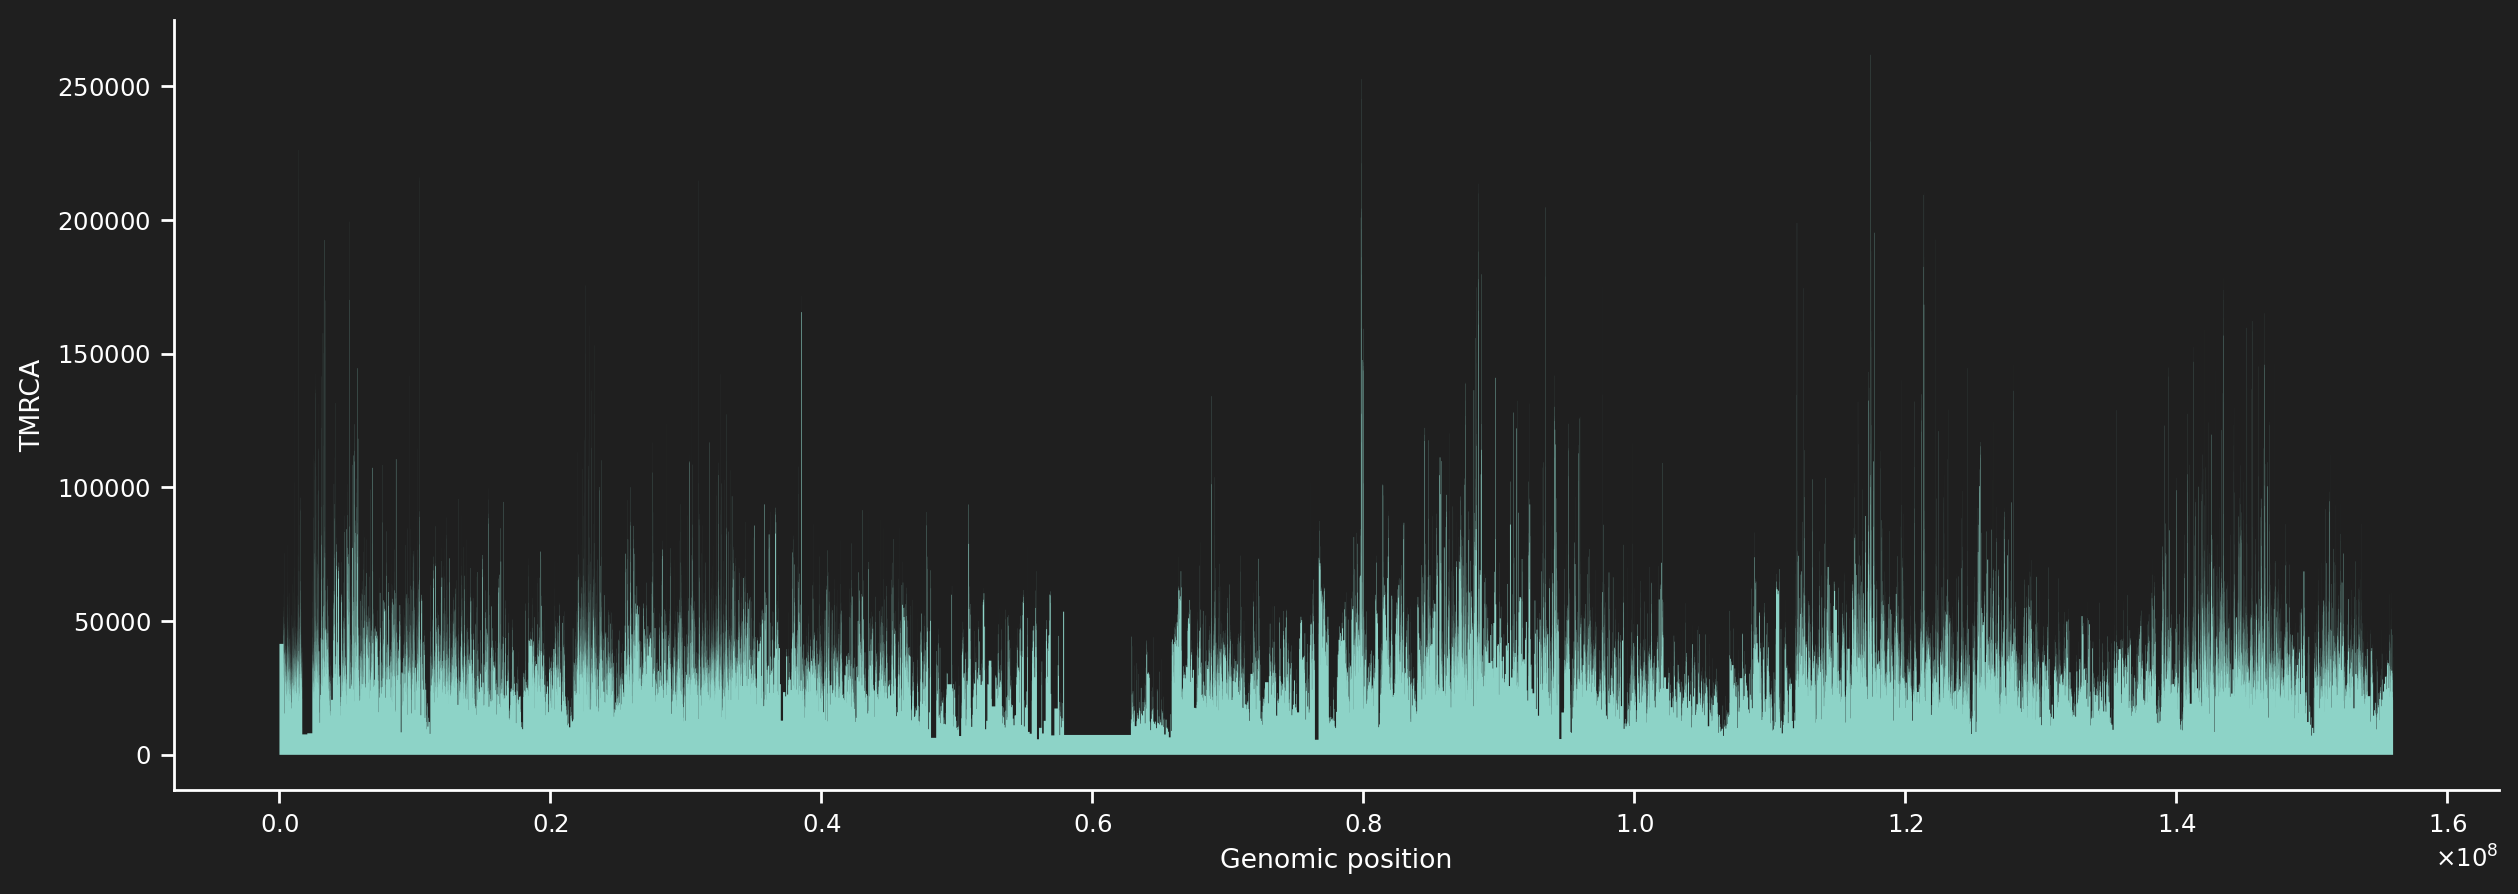

<Figure size 500x370 with 0 Axes>

In [32]:

# Stairs plot
with vscode_theme(style='ticks'):
    fig, ax = plt.subplots(figsize=(15, 5))
    # plt.step(lefts, tmrcas, where='post', linewidth=0)
    plt.fill_between(lefts, tmrcas, step='post', edgecolor='none')
    plt.xlabel("Genomic position")
    plt.ylabel("TMRCA")
    plt.show()
